In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Classification.classification_dataset_preprocessing import make_delta_pipeline, make_preprocessing_pipeline, make_relative_delta_pipeline

# Wczytywanie danych i wyświetlanie przykładowych rekordów

In [2]:
df = pd.read_csv(os.path.join("../data", "ortodoncja.csv"))
df.head(10)

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
0,28.882655,87.411884,66.908260,0.415477,111.114850,75.585670,74.142998,80.118387,13.603083,-5.975389,...,116.585770,77.233907,76.042877,80.645978,10.223444,-4.603101,1.416613,1.191030,22.220111,horizontal
1,35.410983,90.714247,67.379392,2.480978,123.868967,77.719090,75.980740,77.756093,6.041252,-1.775353,...,120.371230,79.480178,77.289118,83.189766,2.538123,-5.900647,1.500294,2.191060,18.056378,horizontal
2,27.952347,90.827615,65.432107,2.277330,119.958531,78.909186,77.545863,81.804363,4.403767,-4.258501,...,117.981833,80.125853,78.238824,81.127838,4.228677,-2.889014,1.341424,1.887029,22.169193,horizontal
3,25.138396,82.195544,59.619544,2.539409,118.323917,80.678309,78.714113,86.651762,1.864515,-7.937649,...,118.071540,82.430061,80.259569,88.624746,-0.890545,-8.365177,1.355916,2.170492,21.251448,horizontal
4,33.761656,90.240915,65.960066,2.929263,126.728619,76.907767,76.334661,83.908674,14.651077,-7.574013,...,128.441180,76.907972,76.362007,83.320338,13.187977,-6.958331,1.459762,0.545964,18.528448,normal
5,25.218726,81.742507,62.887154,3.224138,115.435298,79.602236,78.385162,81.569279,5.996091,-3.184117,...,111.647589,79.305568,77.745449,80.096742,5.367704,-2.351293,1.325328,1.560119,23.573096,horizontal
6,37.912640,91.005231,72.077863,2.374344,123.175481,72.907680,72.267873,79.890146,7.592982,-7.622273,...,124.302351,75.209968,74.104567,78.292527,7.777666,-4.187961,1.492560,1.105401,18.914343,normal
7,19.982655,85.740678,60.181625,2.007675,108.610114,84.342154,82.717267,86.215982,3.383217,-3.498715,...,111.509919,81.060108,79.039566,82.600611,2.134735,-3.561045,1.317547,2.020542,25.994619,horizontal
8,19.569295,85.776171,61.829243,2.445816,106.542496,83.043444,80.705440,82.398323,3.292104,-1.692882,...,105.518614,82.346144,79.677550,81.115378,3.861846,-1.437828,1.271061,2.668594,26.601858,horizontal
9,29.407508,88.692150,65.548312,3.954003,114.915772,78.118280,76.122110,80.687288,6.887992,-4.565178,...,115.279964,79.936198,76.993814,80.936806,7.457926,-3.942992,1.385404,2.942384,22.583378,horizontal


# Wymiary datasetu (liczba rekordów x liczba cech)

In [3]:
df.shape

(446, 27)

# Informacje o typach cech

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   9_SN/MP            446 non-null    float64
 1   9_Facial axis      446 non-null    float64
 2   9_Y-axis           446 non-null    float64
 3   9_Mn Base angle    446 non-null    float64
 4   9_Mn Ramus Angle   446 non-null    float64
 5   9_SNPog            446 non-null    float64
 6   9_SNB              446 non-null    float64
 7   9_SNA              446 non-null    float64
 8   9_SN/PP            446 non-null    float64
 9   9_ANB              446 non-null    float64
 10  9_AFH:PFH          446 non-null    float64
 11  9_PgNB             446 non-null    float64
 12  9_beta angle       446 non-null    float64
 13  12_SN/MP           446 non-null    float64
 14  12_Facial axis     446 non-null    float64
 15  12_Y-axis          446 non-null    float64
 16  12_Mn Base angle   446 non-null    fl

# Analiza danych numerycznych

### Opis statystycznych danych numerycznych

In [5]:
df.describe()

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_Mn Base angle,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle
count,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,...,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000
mean,33.315033,88.428514,66.637249,1.946258,122.568512,77.290273,76.339302,80.718170,7.204316,-4.378868,...,2.569964,121.245704,78.450767,77.290843,81.212121,7.165841,-3.921278,1.446325,1.160148,20.801461
std,4.664109,3.559692,3.134645,1.407175,5.581123,3.140499,3.046515,3.404900,3.203708,2.058331,...,1.397803,5.566098,3.130976,3.089604,3.452230,3.103847,2.158409,0.075403,0.727387,2.384866
min,19.569295,75.471874,55.264537,-1.855797,106.273890,68.094393,67.770015,72.707404,-3.371575,-9.725989,...,-1.592408,104.789965,70.481570,70.187880,72.099648,-1.292949,-10.293067,1.244515,-1.068884,13.056881
25%,30.083138,85.978142,64.481794,0.921260,118.904444,75.135247,74.086700,78.469479,5.089419,-5.792613,...,1.640817,117.373239,76.424090,75.281835,78.721307,5.238621,-5.370657,1.393239,0.656741,19.067425
50%,33.446964,88.256898,66.430186,1.937554,122.855447,77.308051,76.161821,80.618224,7.085342,-4.480021,...,2.541229,121.047114,78.337574,77.129546,81.119388,7.262479,-4.014321,1.445952,1.162735,20.820688
75%,36.433746,90.737761,68.700723,2.861721,126.266211,79.331829,78.261735,82.869704,9.165975,-2.935589,...,3.437915,125.040958,80.338232,79.223116,83.389647,9.323639,-2.372826,1.501029,1.671685,22.318562
max,49.286542,99.677516,75.115567,6.200186,137.616824,86.862239,84.787099,93.149888,18.750681,0.945465,...,6.987558,139.166983,88.868366,86.982279,92.429272,15.053215,2.579310,1.650425,3.176099,29.655680


### Analiza histogramów

array([[<Axes: title={'center': '9_SN/MP'}>,
        <Axes: title={'center': '9_Facial axis'}>,
        <Axes: title={'center': '9_Y-axis'}>,
        <Axes: title={'center': '9_Mn Base angle'}>,
        <Axes: title={'center': '9_Mn Ramus Angle'}>],
       [<Axes: title={'center': '9_SNPog'}>,
        <Axes: title={'center': '9_SNB'}>,
        <Axes: title={'center': '9_SNA'}>,
        <Axes: title={'center': '9_SN/PP'}>,
        <Axes: title={'center': '9_ANB'}>],
       [<Axes: title={'center': '9_AFH:PFH'}>,
        <Axes: title={'center': '9_PgNB'}>,
        <Axes: title={'center': '9_beta angle'}>,
        <Axes: title={'center': '12_SN/MP'}>,
        <Axes: title={'center': '12_Facial axis'}>],
       [<Axes: title={'center': '12_Y-axis'}>,
        <Axes: title={'center': '12_Mn Base angle'}>,
        <Axes: title={'center': '12_Mn Ramus Angle'}>,
        <Axes: title={'center': '12_SNPog'}>,
        <Axes: title={'center': '12_SNB'}>],
       [<Axes: title={'center': '12_SNA'}>,

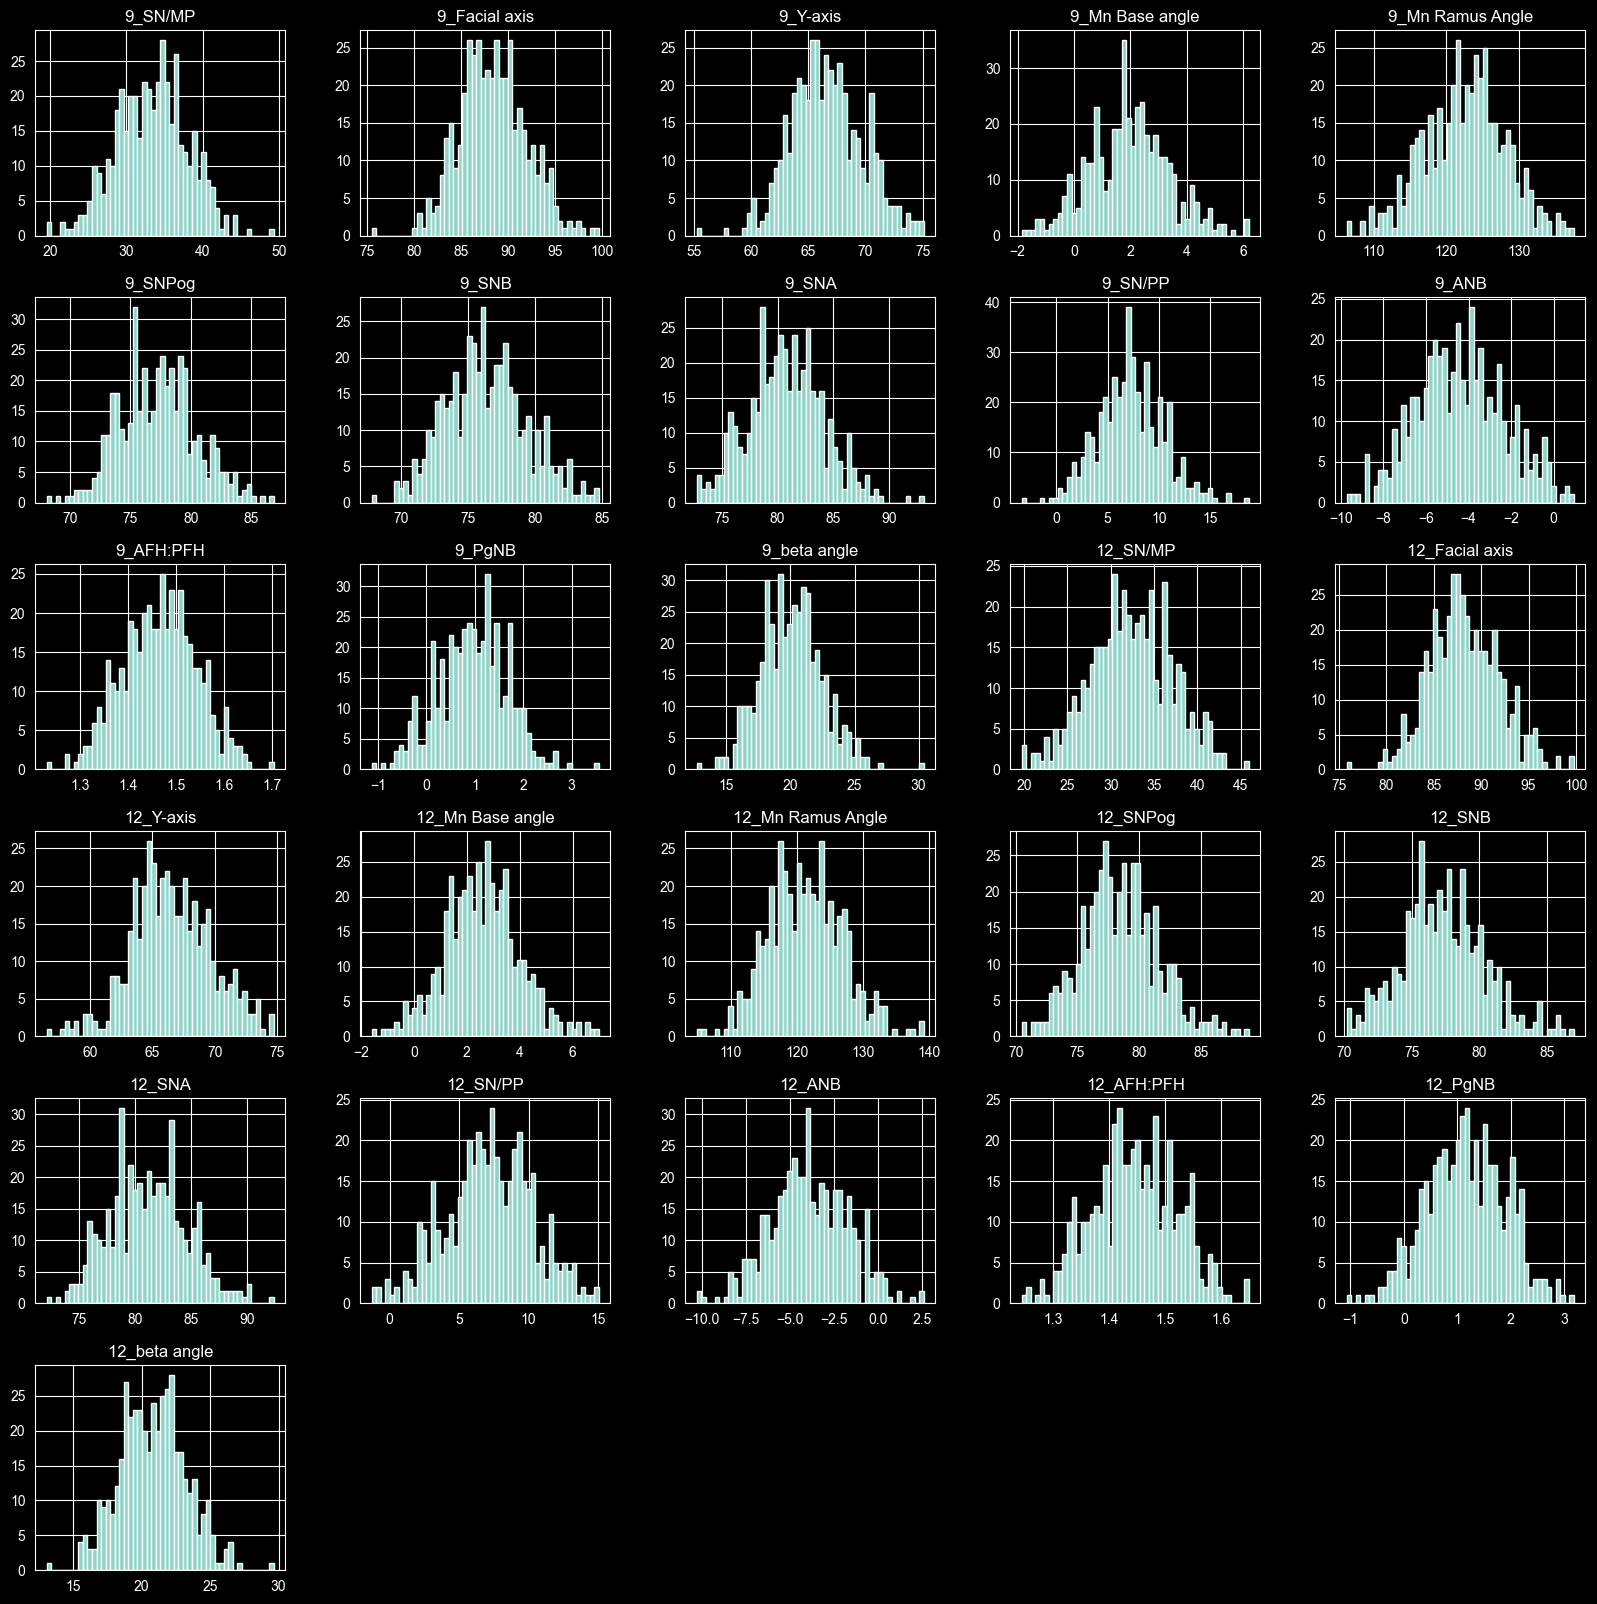

In [6]:
df.hist(figsize=(20,20), bins=50)

In [7]:
df["growth direction"].value_counts()

growth direction
normal        246
horizontal    184
vertical       16
Name: count, dtype: int64

Warto rozszerzyć klasę vertical

### Macierz korelacji

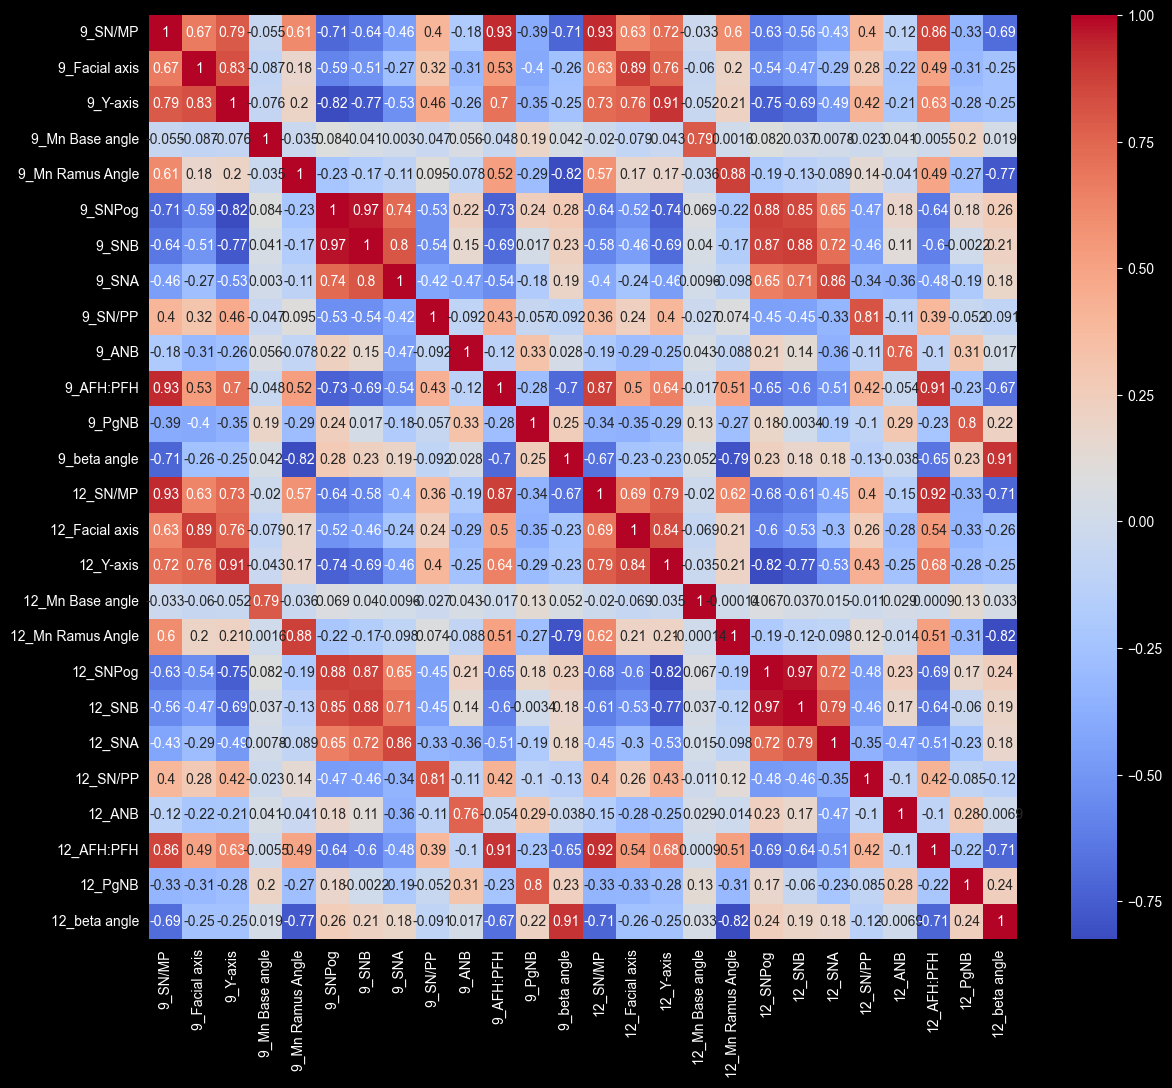

In [8]:
corr = df.select_dtypes(include="number").corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.show()

### Macierze korelacji dla indywidualnych kierunków wzrostu

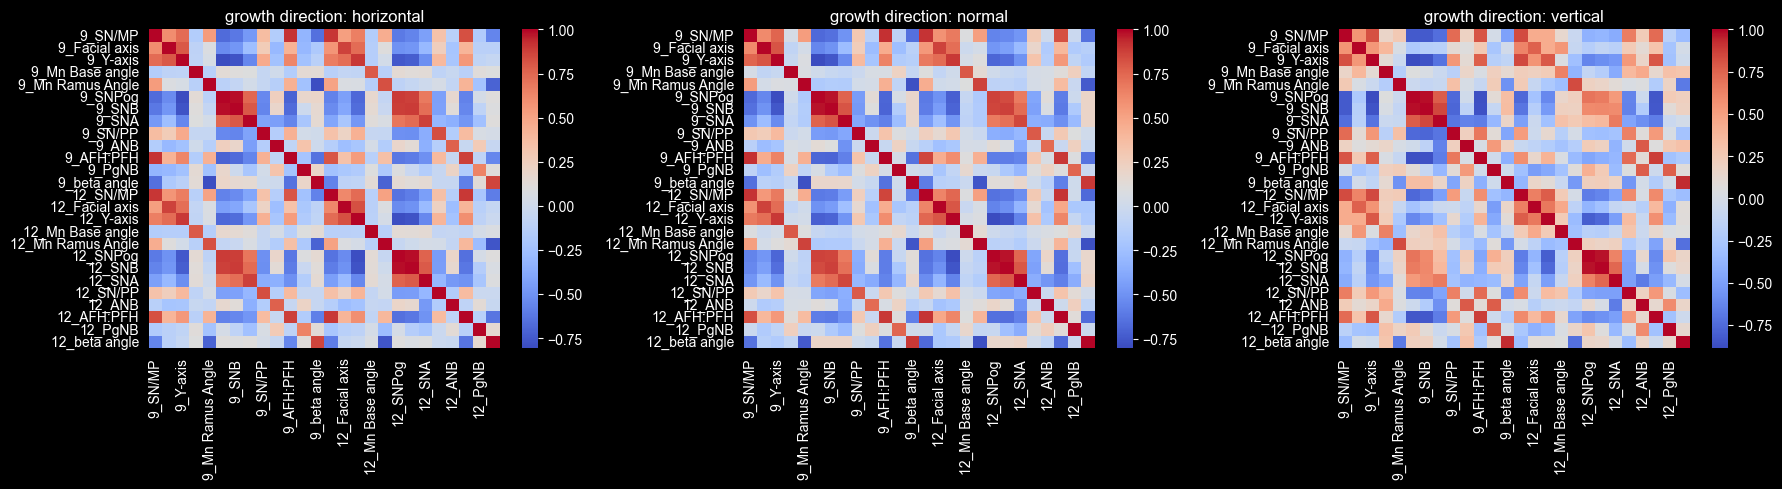

In [9]:
target_col = "growth direction"
labels = df[target_col].unique()

n_cols = 3
n_rows = 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, label in enumerate(labels):
    subset = df[df[target_col] == label].select_dtypes(include="number")
    corr = subset.corr()

    sns.heatmap(corr, cmap="coolwarm", annot=False, fmt=".2f", ax=axes[i])
    axes[i].set_title(f"{target_col}: {label}")

plt.tight_layout()
plt.show()

Kierunki horizontal i normal mają bardzo zbliżone macierze korelacji, kierunek vertical miejscami widocznie się różni.
Dla wszystkich kierunków zachodzi silna korelacja między analogicznymi wartościami dla wieku 9 i 12 (widoczne dodatkowe przekątne), jednak dla pierwszych dwóch wykresów ta korelacja jest zauważalnie silniejsza.

Widać silną korelację sąsiadujacych ze sobą cech Pog, (SNA) i SNB (wyspy na przekątnej).

# Inne

## Komórki z podejrzeniem niedokładnych danych

In [10]:
num_cols = df.select_dtypes(include="number").columns
mask = (df[num_cols] == df[num_cols].round(1)).all(axis=1)
df_inaccurate = df[mask]
df_inaccurate.head()

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
96,40.5,95.1,68.3,2.5,130.0,77.9,77.0,77.4,7.0,-0.4,...,132.0,79.6,78.6,78.3,5.3,0.2,1.5,1.1,18.3,vertical
290,32.9,86.1,67.6,1.9,120.3,74.9,73.9,80.1,6.0,-6.2,...,122.4,76.5,74.8,80.7,6.0,-5.8,1.5,1.7,19.4,normal
365,37.5,89.4,68.3,2.9,127.1,76.6,76.8,82.4,6.7,-5.6,...,131.3,72.9,71.7,75.6,10.4,-3.9,1.5,1.2,16.9,vertical


Pozostałe rekordy mają dużo miejsc po przecinku, należy się zastanowić czy powyższe dane nie są za mało dokładne

In [11]:
def check_records_typicality(df, suspect_mask, target_column, n_std=2):
    stats = df[~suspect_mask].groupby(target_column).agg(["mean", "std"])

    suspect_records = df[suspect_mask]
    num_cols = df.select_dtypes(include="number").columns.tolist()

    results = []
    for idx, row in suspect_records.iterrows():
        label = row[target_column]
        outlier_cols = []

        for col in num_cols:
            mean = stats.loc[label, (col, "mean")]
            std = stats.loc[label, (col, "std")]
            if abs(row[col] - mean) > n_std * std:
                outlier_cols.append(col)

        results.append({
            "index": idx,
            "label": label,
            "outlier_columns": outlier_cols,
            "is_typical": len(outlier_cols) == 0
        })

    return pd.DataFrame(results)

report = check_records_typicality(df, mask,"growth direction",2)
print(report)

   index     label outlier_columns  is_typical
0     96  vertical         [9_ANB]       False
1    290    normal              []        True
2    365  vertical        [12_SNB]       False


Prosty test statystyczny nie pokazuje dużych odchyleń, zatem zostawiam te dane

# Analiza po wykonaniu preprocessing pipeline - SMOTE i standardyzacja

In [12]:
pipeline = make_preprocessing_pipeline()
df_transformed = pipeline.fit_transform(df)

label_encoder = pipeline.named_steps["encode_labels"].encoder
label_encoder.inverse_transform([0, 1, 2])

df_transformed.head(10)

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
0,-0.951383,-0.285916,0.086554,-1.089061,-2.054519,-0.543390,-0.721733,-0.176351,1.999543,-0.776510,...,-0.838139,-0.389088,-0.404378,-0.164177,0.986207,-0.316246,-0.394496,0.042503,0.595523,0
1,0.449883,0.642837,0.237021,0.380422,0.233271,0.136698,-0.117828,-0.870922,-0.363445,1.266287,...,-0.157284,0.329152,-0.000559,0.573503,-1.492636,-0.918080,0.716537,1.418873,-1.152335,0
2,-1.151068,0.674720,-0.384890,0.235539,-0.468170,0.516074,0.396491,0.319367,-0.875140,0.058544,...,-0.587042,0.535605,0.307174,-0.024441,-0.947361,0.478789,-1.392779,1.000427,0.574149,0
3,-1.755066,-1.752952,-2.241270,0.421992,-0.761381,1.080032,0.780393,1.744620,-1.668628,-1.730906,...,-0.570908,1.272371,0.961955,2.149610,-2.598528,-2.061189,-1.200363,1.390565,0.188896,0
4,0.095865,0.509717,-0.216275,0.699351,0.746226,-0.121935,-0.001525,0.938085,2.327029,-1.554042,...,1.294184,-0.493306,-0.300970,0.611368,1.942396,-1.408660,0.178391,-0.845319,-0.954169,1
5,-1.737824,-1.880364,-1.197681,0.909137,-1.279532,0.737004,0.672295,0.250247,-0.377557,0.581098,...,-1.726325,0.273321,0.147306,-0.323452,-0.579976,0.728197,-1.606483,0.550491,1.163481,0
6,0.986849,0.724673,1.737589,0.304559,0.108876,-1.397076,-1.337923,-0.243459,0.121454,-1.577515,...,0.549771,-1.036239,-1.032448,-0.846662,0.197340,-0.123694,0.613863,-0.075350,-0.792177,1
7,-2.861715,-0.755923,-2.061756,0.043695,-2.503810,2.247987,2.095879,1.616490,-1.194051,0.428085,...,-1.751086,0.834331,0.566638,0.402653,-1.622746,0.167085,-1.709801,1.184184,2.179992,0
8,-2.950440,-0.745941,-1.535550,0.355406,-2.874693,1.833986,1.434768,0.494006,-1.222522,1.306399,...,-2.828687,1.245539,0.773363,-0.028055,-1.065679,1.151885,-2.326993,2.076117,2.434900,0
9,-0.838727,0.074145,-0.347778,1.428394,-1.372723,0.263951,-0.071372,-0.009080,-0.098848,-0.090617,...,-1.073003,0.474963,-0.096246,-0.079839,0.094210,-0.010072,-0.808851,2.452942,0.748016,0


## Analiza statystyczna

In [13]:
df_transformed.describe()

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
count,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,...,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.00000
mean,0.386151,0.228862,0.191306,0.066077,0.386764,-0.126255,-0.085032,-0.135490,0.184341,0.098273,...,0.473714,-0.123096,-0.076499,-0.147920,0.230231,0.126503,0.371642,-0.203317,-0.483657,1.00000
std,1.126870,0.979618,0.968062,0.884429,1.110610,0.920008,0.899539,0.948386,1.012833,0.933679,...,1.197351,0.937105,0.906380,0.956000,0.988442,0.972590,1.099142,1.003453,1.180917,0.81705
min,-2.950440,-3.643908,-3.632145,-2.704940,-2.922874,-2.931447,-2.815975,-2.355359,-3.304847,-2.600711,...,-2.959743,-2.548134,-2.301570,-2.642554,-2.728320,-2.955392,-2.679443,-3.067881,-3.251032,0.00000
25%,-0.484226,-0.505480,-0.455615,-0.356447,-0.337040,-0.689515,-0.651524,-0.773997,-0.436830,-0.547714,...,-0.511288,-0.732142,-0.648226,-0.857777,-0.436985,-0.595351,-0.441274,-0.880245,-1.558304,0.00000
50%,0.494291,0.338148,0.181885,0.031130,0.529840,-0.301928,-0.161620,-0.111806,0.083711,0.026372,...,0.507731,-0.305129,-0.197476,-0.227550,0.344325,0.108123,0.497131,-0.158716,-0.560909,1.00000
75%,1.254918,0.941252,0.870496,0.562112,1.125964,0.438515,0.457776,0.483332,0.829221,0.752551,...,1.464592,0.432462,0.447025,0.551356,0.984719,0.924784,1.305764,0.514695,0.418728,2.00000
max,3.428189,3.163654,2.707751,3.026422,2.699316,3.051335,2.776052,3.655226,3.608110,2.589628,...,3.223336,3.331005,3.140311,3.252896,2.544014,3.015132,2.709831,2.774611,3.716838,2.00000


## Histogramy


array([[<Axes: title={'center': '9_SN/MP'}>,
        <Axes: title={'center': '9_Facial axis'}>,
        <Axes: title={'center': '9_Y-axis'}>,
        <Axes: title={'center': '9_Mn Base angle'}>,
        <Axes: title={'center': '9_Mn Ramus Angle'}>],
       [<Axes: title={'center': '9_SNPog'}>,
        <Axes: title={'center': '9_SNB'}>,
        <Axes: title={'center': '9_SNA'}>,
        <Axes: title={'center': '9_SN/PP'}>,
        <Axes: title={'center': '9_ANB'}>],
       [<Axes: title={'center': '9_AFH:PFH'}>,
        <Axes: title={'center': '9_PgNB'}>,
        <Axes: title={'center': '9_beta angle'}>,
        <Axes: title={'center': '12_SN/MP'}>,
        <Axes: title={'center': '12_Facial axis'}>],
       [<Axes: title={'center': '12_Y-axis'}>,
        <Axes: title={'center': '12_Mn Base angle'}>,
        <Axes: title={'center': '12_Mn Ramus Angle'}>,
        <Axes: title={'center': '12_SNPog'}>,
        <Axes: title={'center': '12_SNB'}>],
       [<Axes: title={'center': '12_SNA'}>,

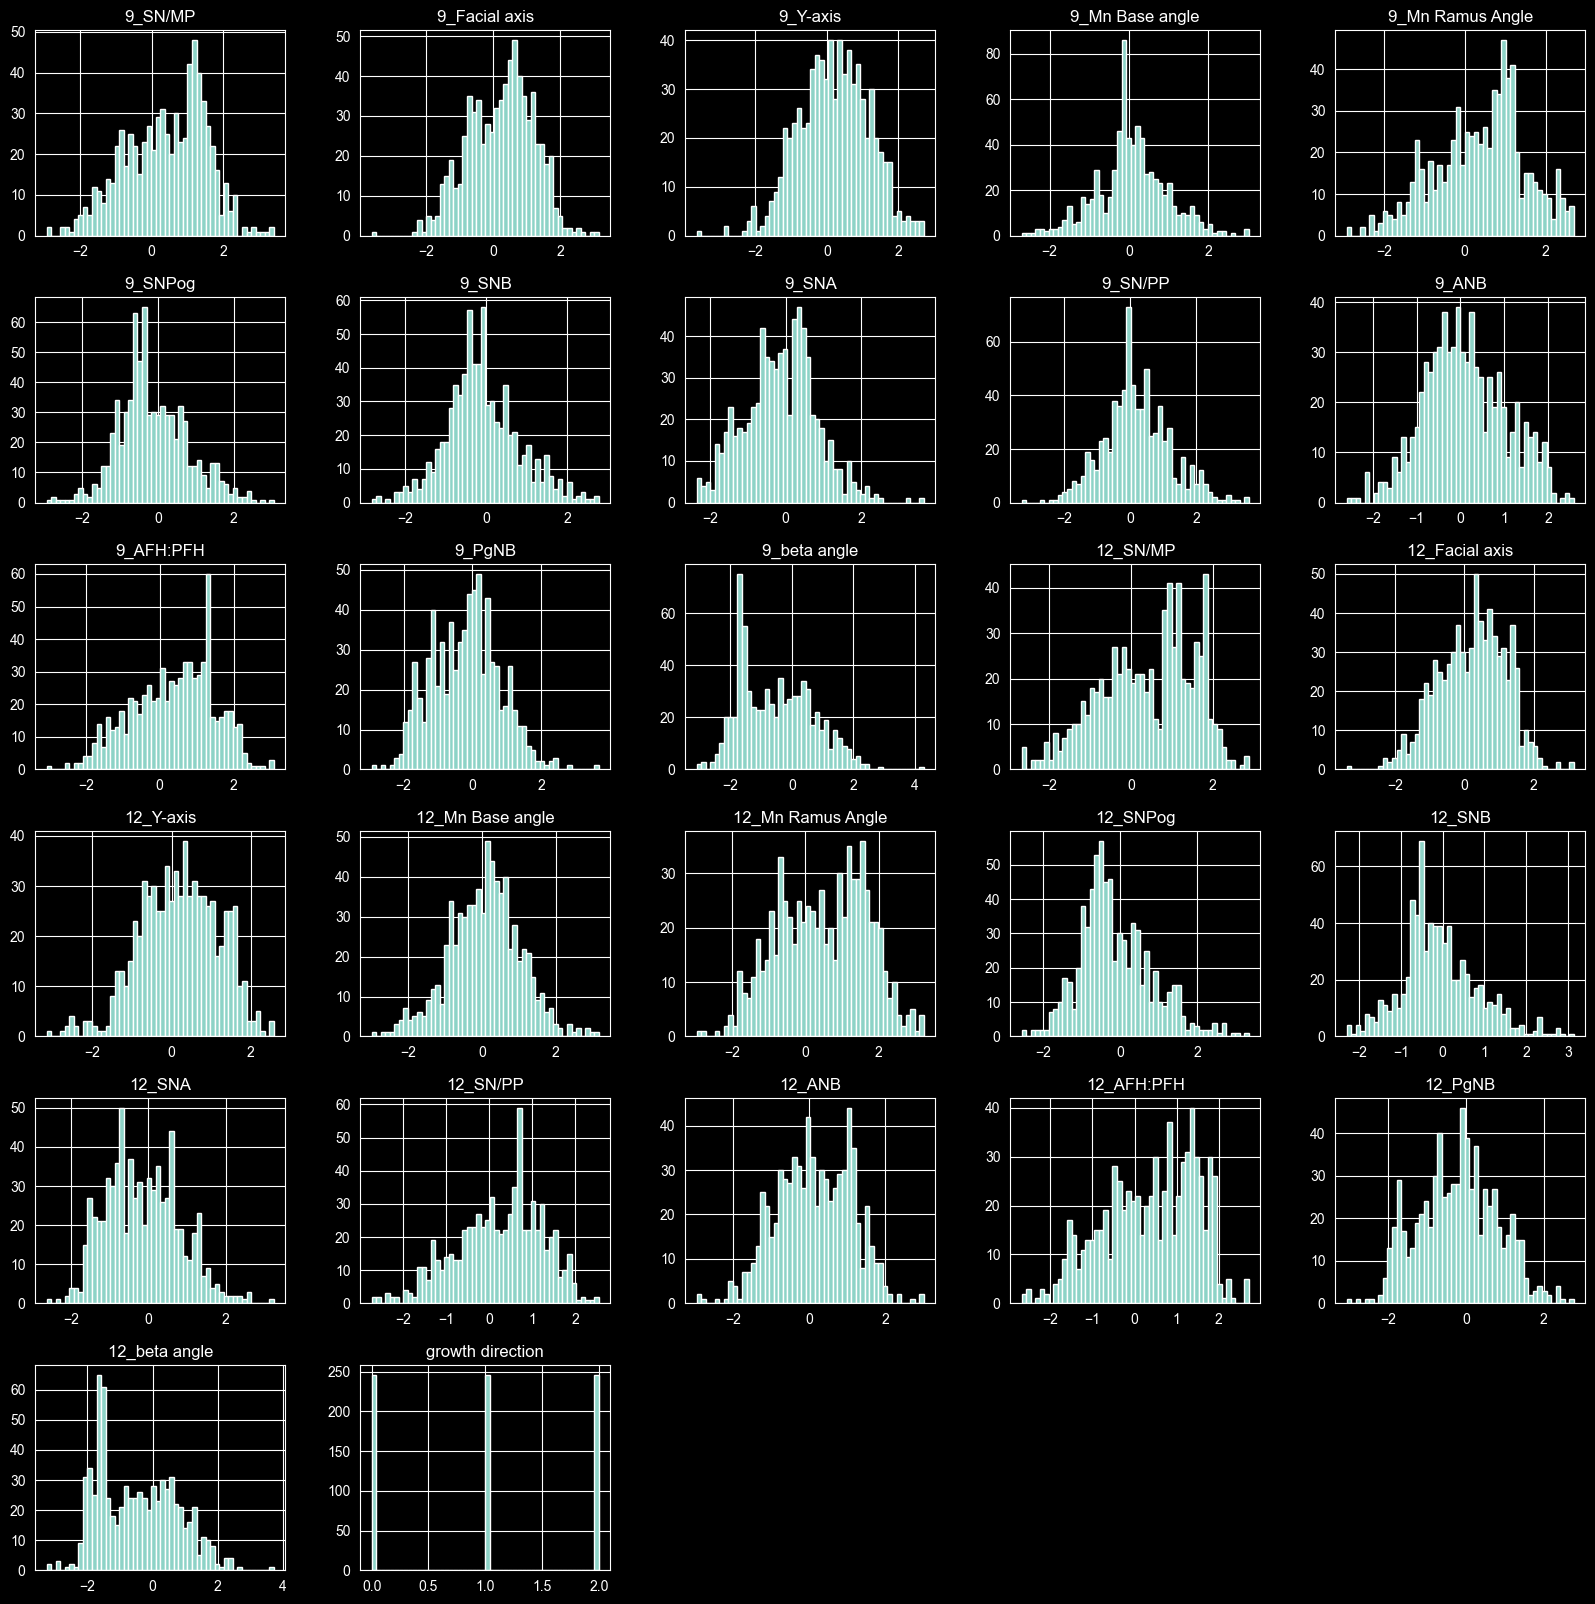

In [14]:
df_transformed.hist(figsize=(20,20), bins=50)

## Macierz korelacji


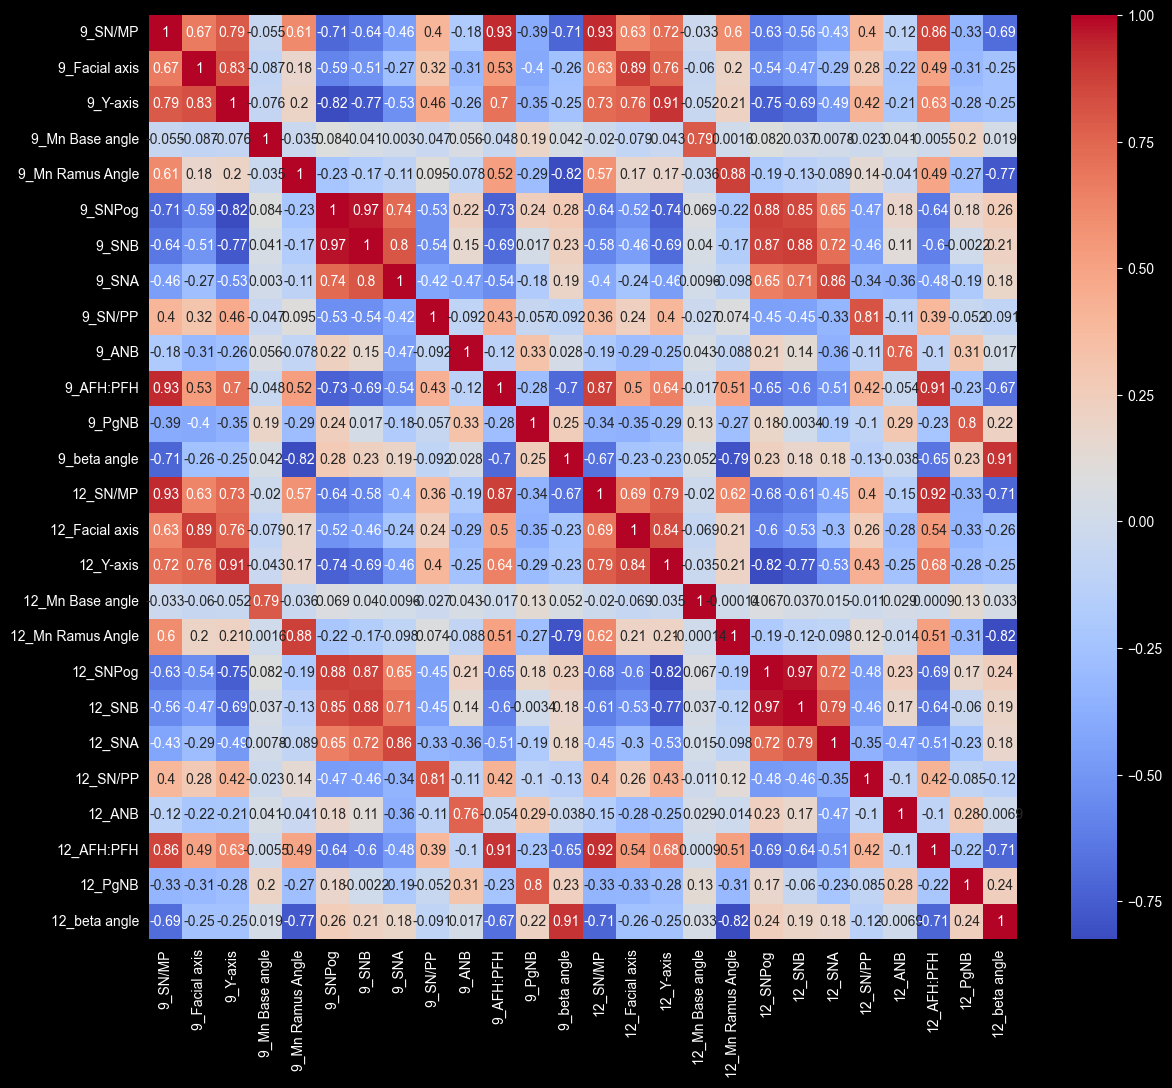

In [15]:
corr = df.select_dtypes(include="number").corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.show()

### Korelacja dla indywidualnych cech

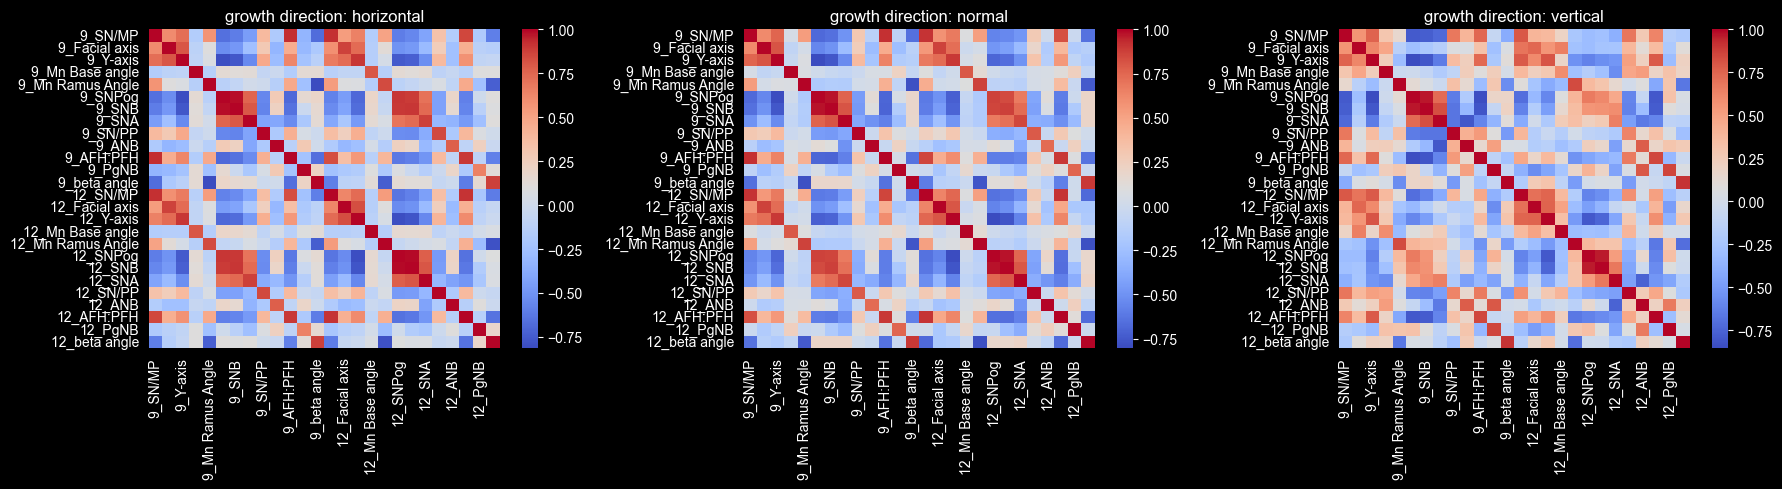

In [16]:
target_col = "growth direction"
labels = sorted(df_transformed[target_col].unique())

n_cols = 3
n_rows = 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i,label in enumerate(labels):
    subset = df_transformed[df_transformed[target_col] == label]
    subset = subset.drop(columns=[target_col])
    subset = subset.select_dtypes(include="number")
    corr = subset.corr()

    sns.heatmap(corr, cmap="coolwarm", annot=False, fmt=".2f", ax=axes[i])
    label_name = label_encoder.inverse_transform([label])[0]
    axes[i].set_title(f"{target_col}: {label_name}")

plt.tight_layout()
plt.show()

Dla kierunku vertical korelacja między wiekiem 9 a 12 nadal jest słabsza niż dla pozostałych

# Zamiana danych na różnicę wartości między wiekiem 9 a 12

In [27]:
delta_pipeline = make_relative_delta_pipeline()
df2 = delta_pipeline.fit_transform(df)

df2.head(10)

,delta_Mn Ramus Angle,delta_SNB,delta_Facial axis,delta_SN/PP,delta_Mn Base angle,delta_PgNB,delta_ANB,delta_beta angle,delta_SN/MP,delta_SNPog,delta_Y-axis,delta_AFH:PFH,delta_SNA,growth direction
0,0.046926,0.024984,-0.009644,-0.330577,0.753560,-0.211281,-0.298122,-0.012978,-0.034856,0.021341,-0.018322,0.001784,0.006542,horizontal
1,-0.029058,0.016928,-0.004040,-1.380204,-0.158363,0.206617,0.699126,-0.055933,-0.049409,0.022158,0.003972,0.025645,0.065317,horizontal
2,-0.016754,0.008857,-0.013286,-0.041405,0.347884,0.277530,-0.474032,0.015618,-0.010572,0.015184,-0.005225,-0.001739,-0.008339,horizontal
3,-0.002137,0.019256,-0.004562,3.093678,0.260944,0.095046,0.051108,-0.037004,-0.039889,0.021251,0.000449,-0.000350,0.022262,horizontal
4,0.013333,0.000358,0.002172,-0.110942,-0.037104,-0.049713,-0.088481,-0.007135,-0.012821,0.000003,-0.000705,-0.000131,-0.007061,normal
5,-0.033926,-0.008228,0.036845,-0.117068,0.096482,0.219883,-0.354198,0.041428,-0.035184,-0.003741,0.026265,-0.009036,-0.018384,horizontal
6,0.009066,0.024785,0.002461,0.023745,0.327226,0.421199,-0.820044,-0.050665,0.000212,0.030611,-0.002725,-0.022625,-0.020406,normal
7,0.026005,-0.046530,0.021328,-0.584842,0.386376,0.195816,0.017503,-0.042983,0.148985,-0.040489,0.027756,0.066203,-0.043769,horizontal
8,-0.009703,-0.012901,-0.003551,0.147531,-0.009338,0.123882,-0.177389,0.025782,0.007078,-0.008468,0.001347,-0.000518,-0.015816,horizontal
9,0.003159,0.011322,-0.024027,0.076420,-0.056074,0.321581,-0.157795,0.044641,-0.063496,0.022742,-0.013605,-0.025714,0.003083,horizontal


In [28]:
df2.describe()

,delta_Mn Ramus Angle,delta_SNB,delta_Facial axis,delta_SN/PP,delta_Mn Base angle,delta_PgNB,delta_ANB,delta_beta angle,delta_SN/MP,delta_SNPog,delta_Y-axis,delta_AFH:PFH,delta_SNA
count,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000,446.000000
mean,-0.011176,0.012121,-0.002464,-0.009635,0.305415,0.137412,1.869898,0.032828,-0.032720,0.014636,-0.001760,-0.013850,0.005810
std,0.022863,0.019368,0.019698,1.169101,2.467554,2.199679,31.790746,0.048462,0.055783,0.019226,0.020174,0.022309,0.022789
min,-0.079725,-0.071130,-0.074447,-13.199290,-34.820900,-18.264676,-20.989294,-0.116728,-0.237184,-0.063338,-0.079749,-0.083937,-0.108417
25%,-0.025624,0.000529,-0.014666,-0.183888,0.048628,-0.066895,-0.381004,0.000178,-0.065533,0.002074,-0.015244,-0.027504,-0.006361
50%,-0.011072,0.011736,-0.001574,0.011385,0.229945,0.173157,-0.091647,0.031190,-0.030373,0.014714,-0.000683,-0.014195,0.006445
75%,0.003195,0.023519,0.009212,0.164129,0.473408,0.441696,0.126330,0.065586,0.004545,0.025580,0.011486,0.001061,0.019446
max,0.073906,0.065981,0.065325,12.537246,28.938890,18.700222,574.327062,0.174683,0.154537,0.076789,0.057691,0.080621,0.068543


array([[<Axes: title={'center': 'delta_Mn Ramus Angle'}>,
        <Axes: title={'center': 'delta_SNB'}>,
        <Axes: title={'center': 'delta_Facial axis'}>,
        <Axes: title={'center': 'delta_SN/PP'}>],
       [<Axes: title={'center': 'delta_Mn Base angle'}>,
        <Axes: title={'center': 'delta_PgNB'}>,
        <Axes: title={'center': 'delta_ANB'}>,
        <Axes: title={'center': 'delta_beta angle'}>],
       [<Axes: title={'center': 'delta_SN/MP'}>,
        <Axes: title={'center': 'delta_SNPog'}>,
        <Axes: title={'center': 'delta_Y-axis'}>,
        <Axes: title={'center': 'delta_AFH:PFH'}>],
       [<Axes: title={'center': 'delta_SNA'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

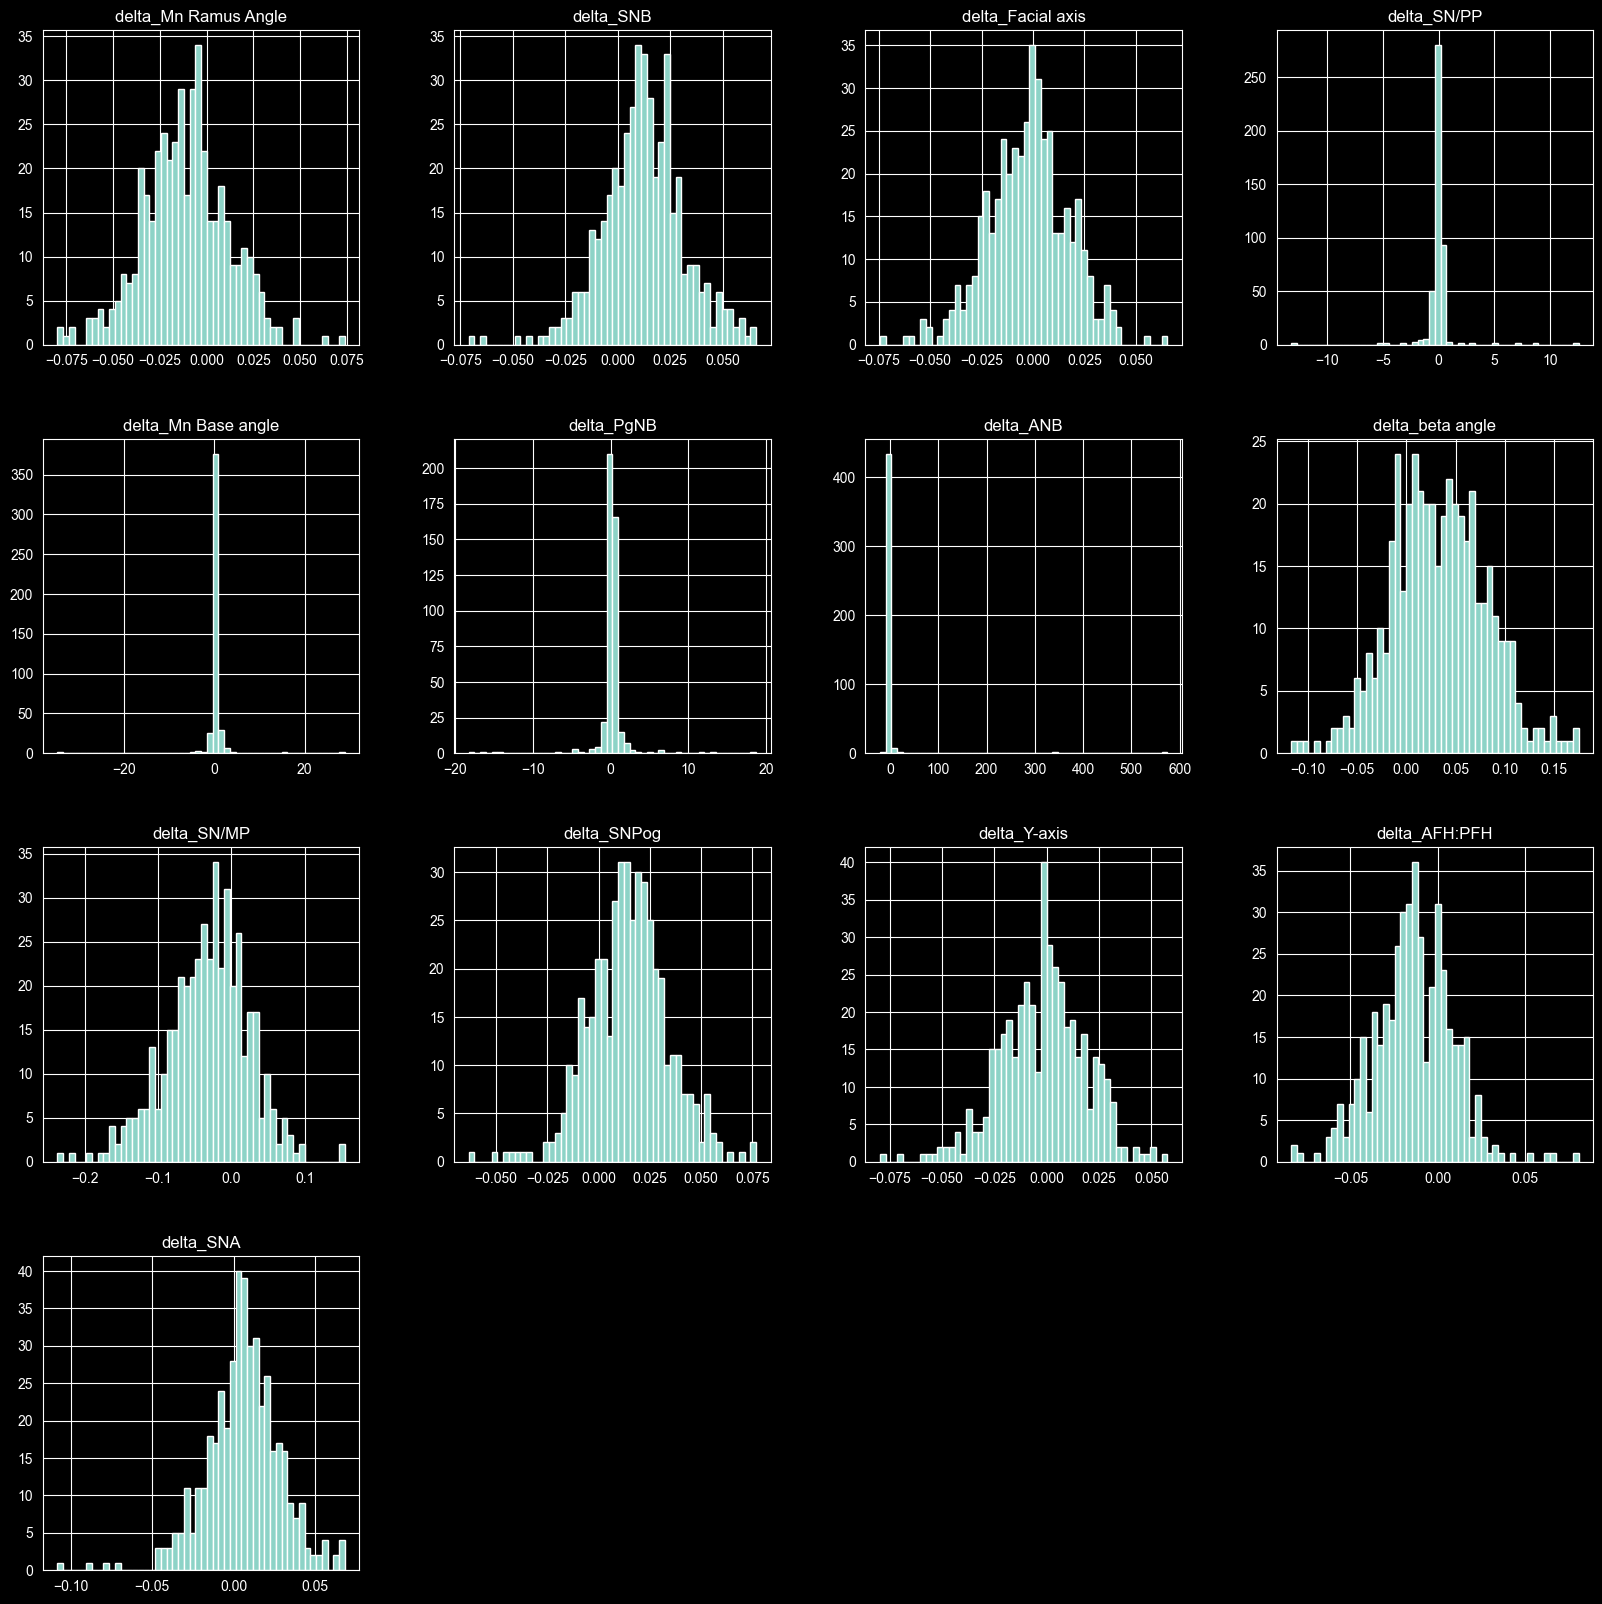

In [19]:
df2.hist(figsize=(20,20), bins=50)

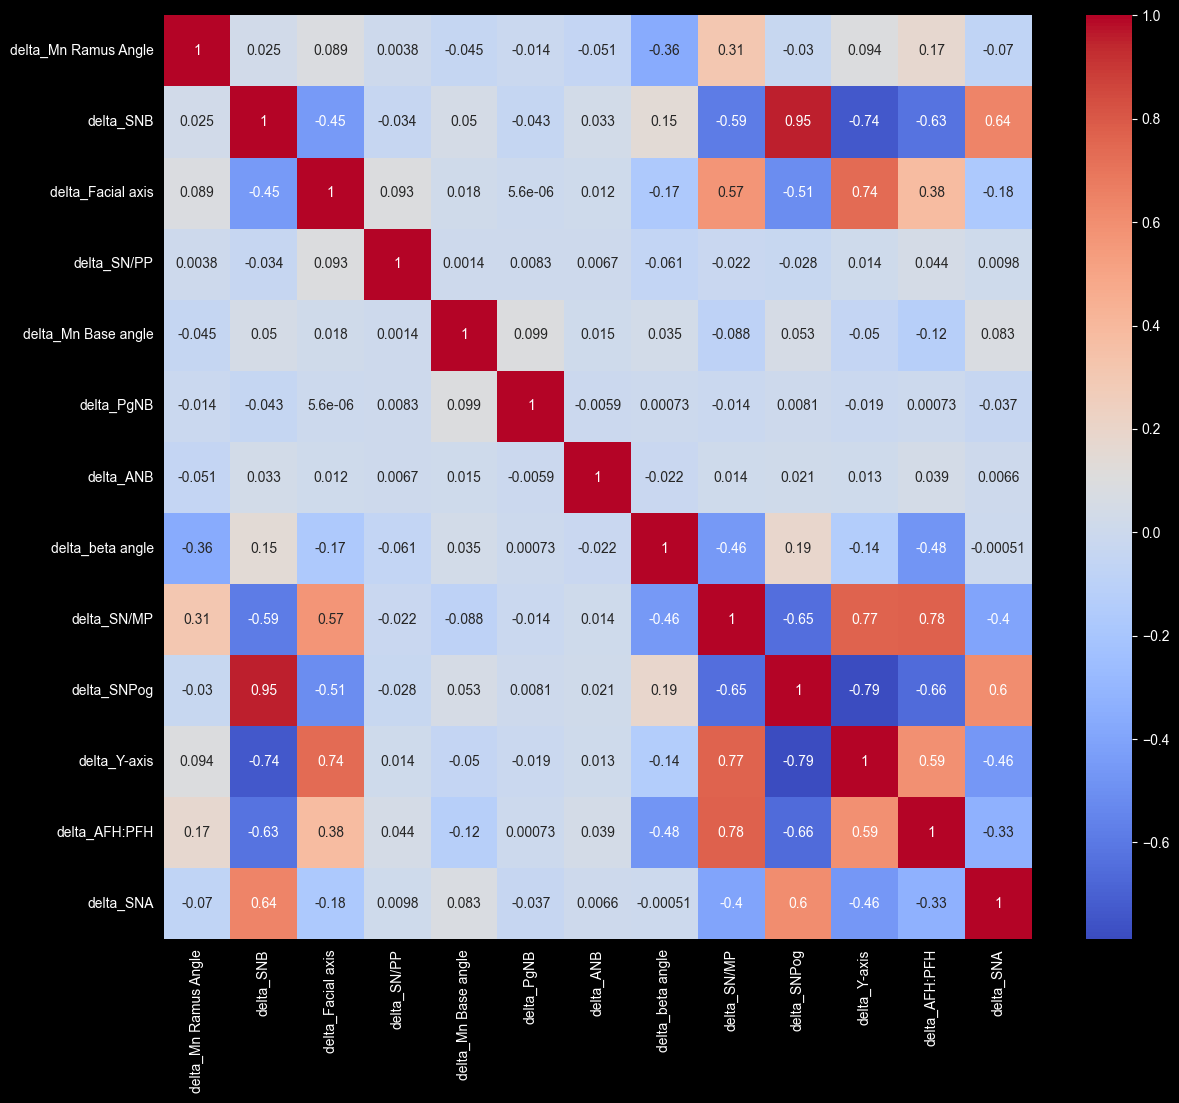

In [20]:
corr = df2.select_dtypes(include="number").corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.show()

Ze względu na wysoką korelację możnaby odchudzić model o jeden z elementów pary SNPog, SNB

## Po zbalansowaniu i standardyzacji

In [21]:
pipeline = make_preprocessing_pipeline()
df2_transformed = pipeline.fit_transform(df2)

df2_transformed.head(10)

,delta_Mn Ramus Angle,delta_SNB,delta_Facial axis,delta_SN/PP,delta_Mn Base angle,delta_PgNB,delta_ANB,delta_beta angle,delta_SN/MP,delta_SNPog,delta_Y-axis,delta_AFH:PFH,delta_SNA,growth direction
0,2.544180,0.664911,-0.364955,-0.274829,0.181819,-0.158698,-0.068273,-0.946264,-0.038341,0.349119,-0.821887,0.701583,0.032137,0
1,-0.782995,0.248495,-0.080096,-1.173644,-0.188162,0.031497,-0.036869,-1.833631,-0.299510,0.391647,0.284468,1.772398,2.614079,0
2,-0.244245,-0.168718,-0.550030,-0.027205,0.017230,0.063771,-0.073813,-0.355518,0.397487,0.028547,-0.171975,0.543477,-0.621582,0
3,0.395791,0.368797,-0.106629,2.657425,-0.018043,-0.019282,-0.057276,-1.442602,-0.128662,0.344460,0.109616,0.605833,0.722717,0
4,1.073229,-0.608030,0.235586,-0.086751,-0.138965,-0.085165,-0.061671,-0.825557,0.357119,-0.761992,0.052340,0.615641,-0.565446,1
5,-0.996140,-1.051866,1.997773,-0.091997,-0.084767,0.037534,-0.070039,0.177669,-0.044229,-0.956922,1.390739,0.216024,-1.062876,0
6,0.886348,0.654617,0.250259,0.028584,0.008849,0.129158,-0.084709,-1.724810,0.591015,0.831854,-0.047878,-0.393798,-1.151670,1
7,1.628085,-3.031694,1.209149,-0.492560,0.032847,0.026581,-0.058334,-1.566100,3.260985,-2.870457,1.464706,3.592483,-2.178020,0
8,0.064500,-1.293381,-0.055245,0.134584,-0.127700,-0.006158,-0.064471,-0.145563,0.714243,-1.203068,0.154178,0.598299,-0.950056,0
9,0.627722,-0.041314,-1.095930,0.073690,-0.146661,0.083819,-0.063854,0.244040,-0.552316,0.422085,-0.587813,-0.532394,-0.119823,0


In [22]:
df2_transformed.describe()

,delta_Mn Ramus Angle,delta_SNB,delta_Facial axis,delta_SN/PP,delta_Mn Base angle,delta_PgNB,delta_ANB,delta_beta angle,delta_SN/MP,delta_SNPog,delta_Y-axis,delta_AFH:PFH,delta_SNA,growth direction
count,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.000000,738.00000
mean,0.184612,0.094861,-0.034538,-0.018486,-0.000912,0.006365,-0.030246,0.076188,0.030232,0.084627,-0.052647,-0.020681,0.015473,1.00000
std,0.925651,1.038530,0.908264,0.798431,0.791082,0.815372,0.779696,0.871601,0.893788,1.015121,0.945400,0.919171,1.060393,0.81705
min,-3.001576,-4.303272,-3.658399,-11.294550,-14.251261,-8.375199,-0.719859,-3.089538,-3.669425,-4.060231,-3.870157,-3.145225,-5.017963,0.00000
25%,-0.400854,-0.485715,-0.629339,-0.169035,-0.102835,-0.083093,-0.075096,-0.484564,-0.495598,-0.524126,-0.706297,-0.662692,-0.580772,0.00000
50%,0.245231,-0.011674,-0.091832,0.017360,-0.032117,0.022029,-0.062436,0.211655,0.056849,-0.010846,-0.003398,0.013041,0.071828,1.00000
75%,0.877493,0.653193,0.514771,0.134584,0.061800,0.139081,-0.054605,0.621220,0.621200,0.654052,0.599303,0.635562,0.643804,2.00000
max,3.725552,2.784032,3.445211,10.744131,11.617020,8.448347,18.027259,2.930437,3.360622,3.236373,2.950210,4.239493,2.755802,2.00000


array([[<Axes: title={'center': 'delta_Mn Ramus Angle'}>,
        <Axes: title={'center': 'delta_SNB'}>,
        <Axes: title={'center': 'delta_Facial axis'}>,
        <Axes: title={'center': 'delta_SN/PP'}>],
       [<Axes: title={'center': 'delta_Mn Base angle'}>,
        <Axes: title={'center': 'delta_PgNB'}>,
        <Axes: title={'center': 'delta_ANB'}>,
        <Axes: title={'center': 'delta_beta angle'}>],
       [<Axes: title={'center': 'delta_SN/MP'}>,
        <Axes: title={'center': 'delta_SNPog'}>,
        <Axes: title={'center': 'delta_Y-axis'}>,
        <Axes: title={'center': 'delta_AFH:PFH'}>],
       [<Axes: title={'center': 'delta_SNA'}>,
        <Axes: title={'center': 'growth direction'}>, <Axes: >, <Axes: >]],
      dtype=object)

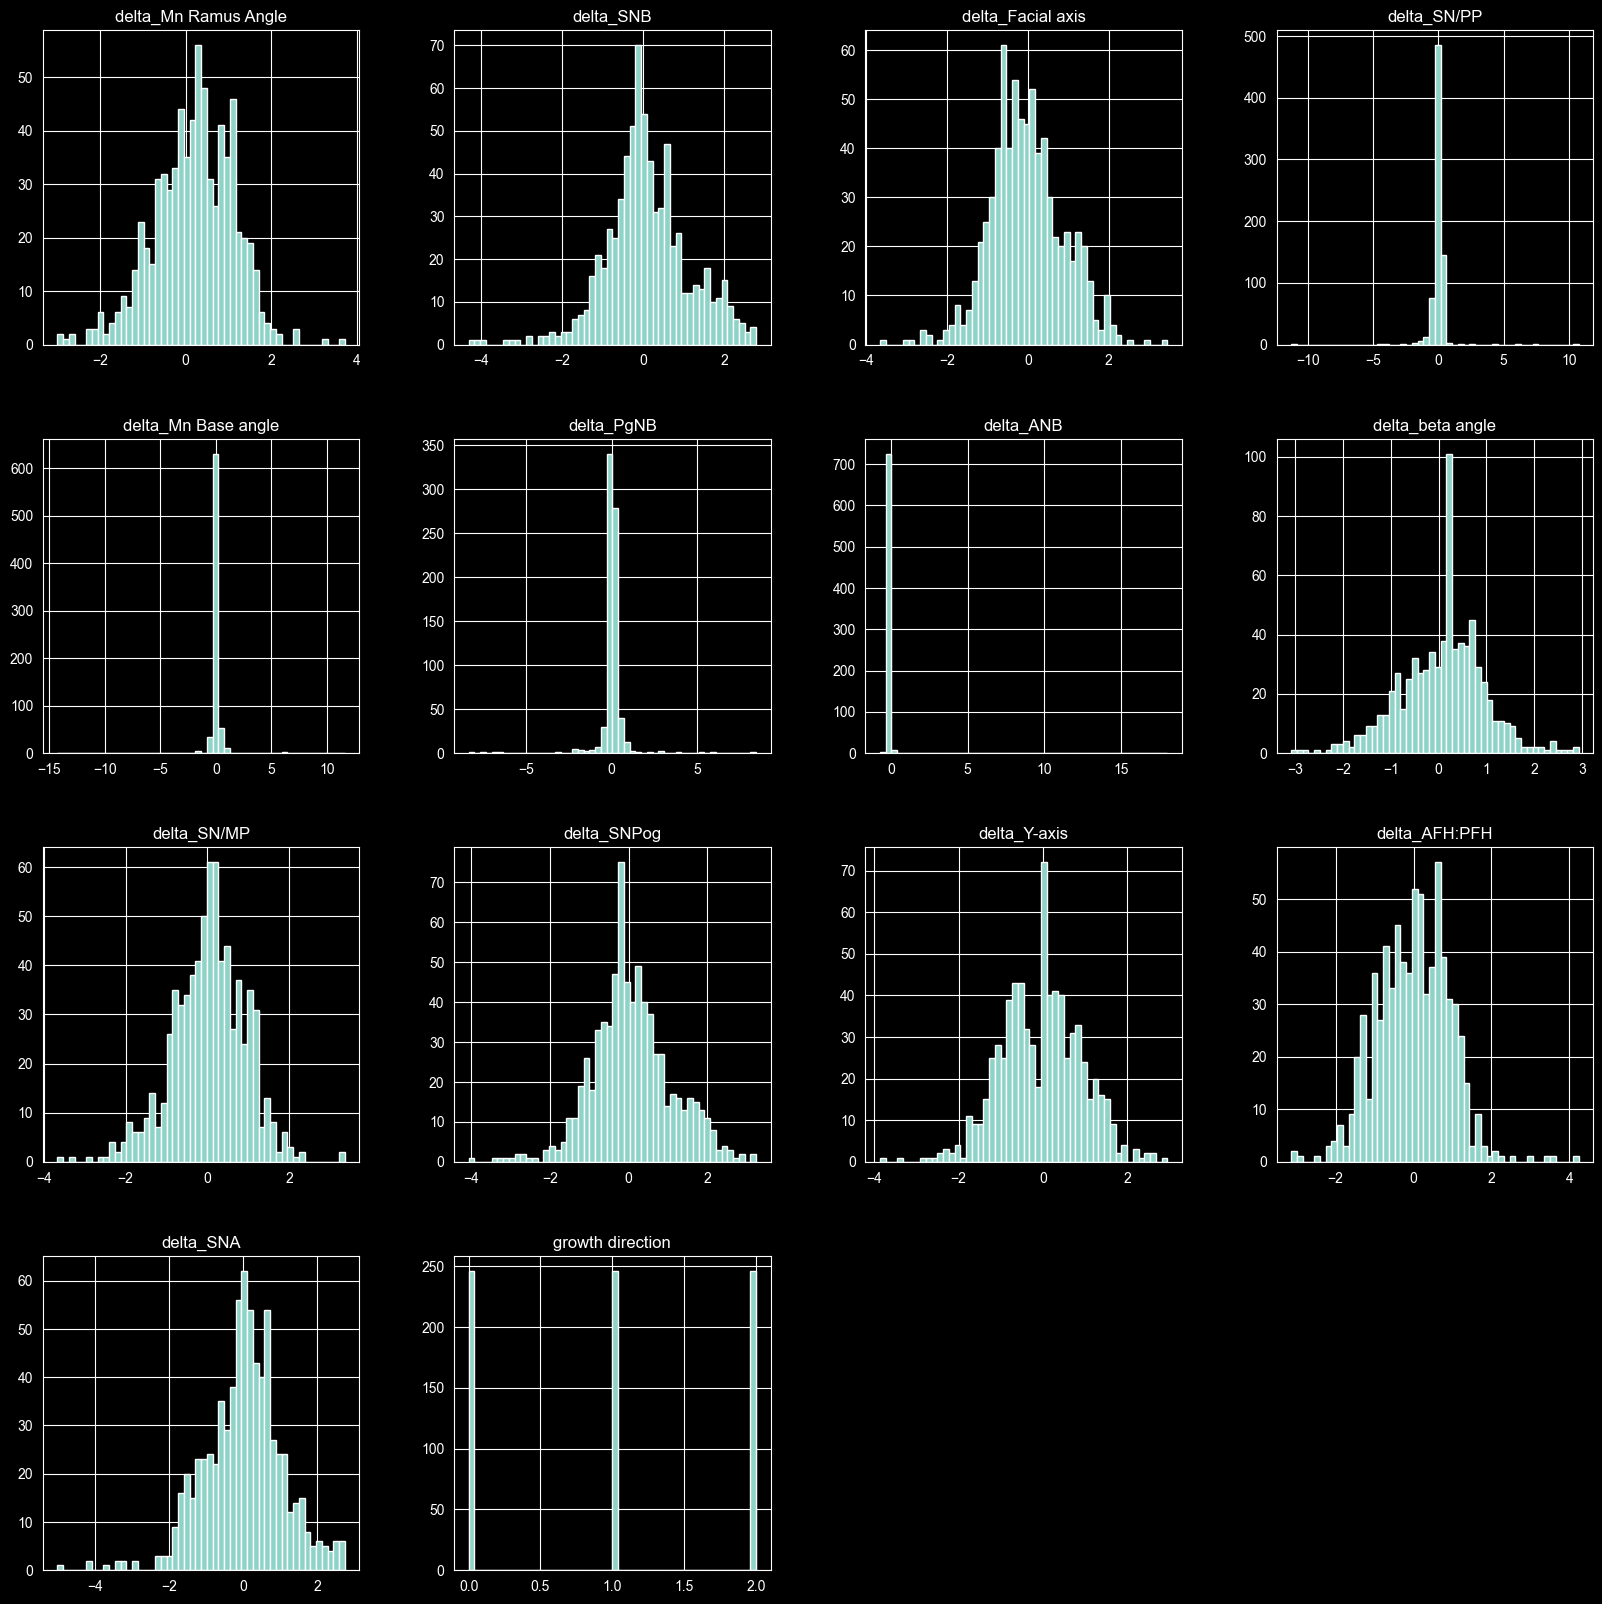

In [23]:
df2_transformed.hist(figsize=(20,20), bins=50)

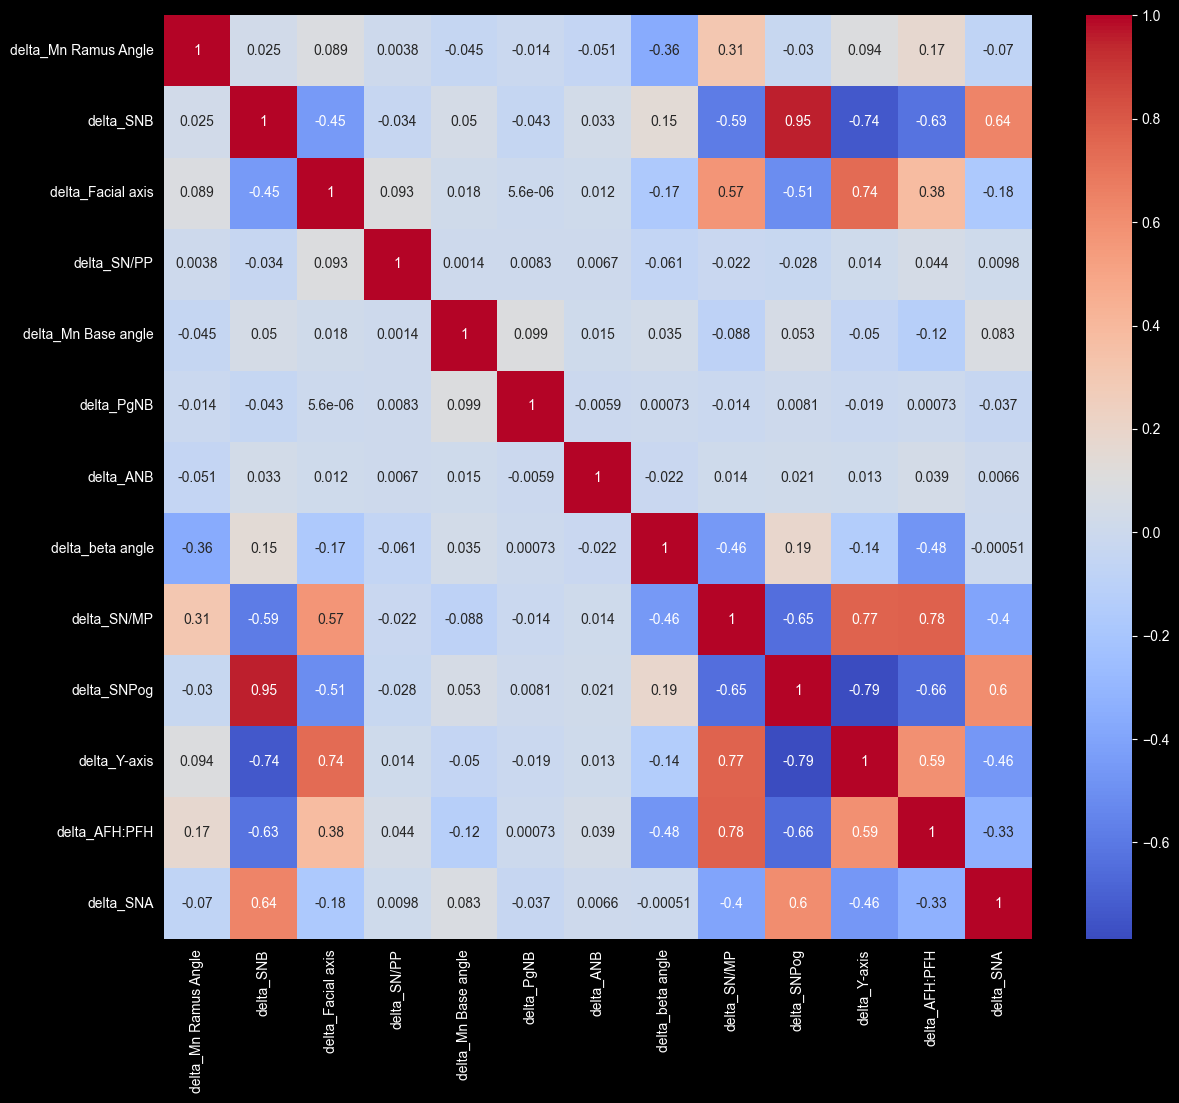

In [24]:
corr = df2.select_dtypes(include="number").corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.show()

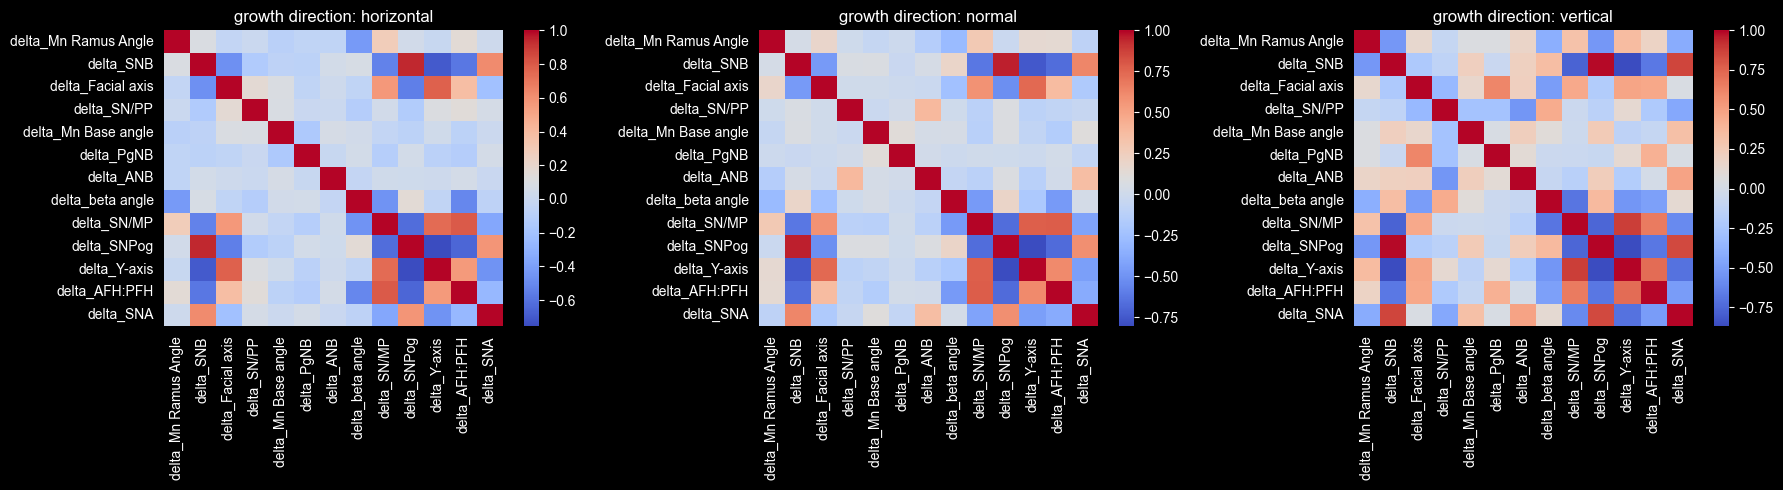

In [25]:
target_col = "growth direction"
labels = sorted(df2_transformed[target_col].unique())

n_cols = 3
n_rows = 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i,label in enumerate(labels):
    subset = df2_transformed[df2_transformed[target_col] == label]
    subset = subset.drop(columns=[target_col])
    subset = subset.select_dtypes(include="number")
    corr = subset.corr()

    sns.heatmap(corr, cmap="coolwarm", annot=False, fmt=".2f", ax=axes[i])
    label_name = label_encoder.inverse_transform([label])[0]
    axes[i].set_title(f"{target_col}: {label_name}")

plt.tight_layout()
plt.show()

### Macierz korelacji delt z kierunkiem wzrostu

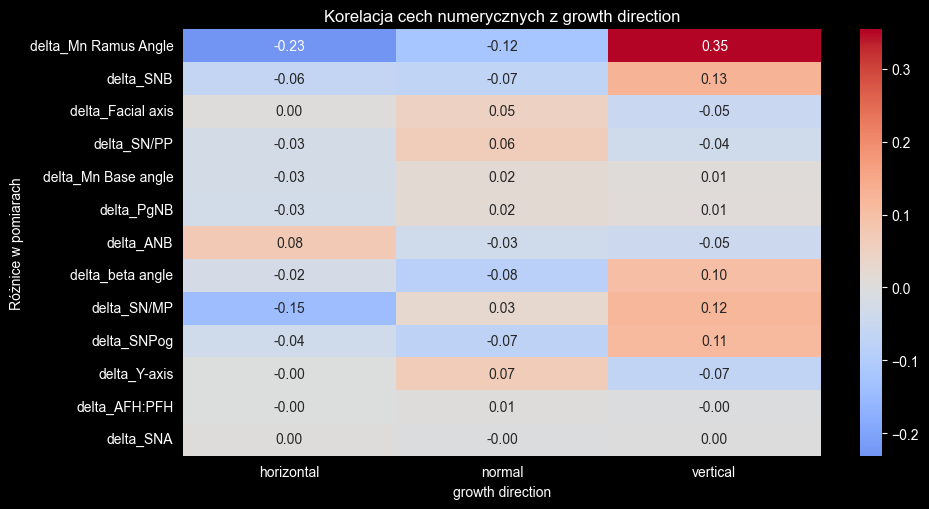

In [26]:
target_col = "growth direction"
labels = sorted(df2_transformed[target_col].unique())

numeric_columns = [col for col in df2_transformed.columns if col != target_col and df2_transformed[col].dtype in ['int64', 'float64']]

correlations = []
class_names = []
for label in labels:
    binary_target = (df2_transformed[target_col] == label).astype(int)
    corr = df2_transformed[numeric_columns].corrwith(binary_target)
    correlations.append(corr)

    label_name = label_encoder.inverse_transform([label])[0]
    class_names.append(label_name)

corr_df = pd.DataFrame(correlations, index=class_names).T

plt.figure(figsize=(10, len(numeric_columns) * 0.4))
sns.heatmap(corr_df, cmap="coolwarm", annot=True, fmt=".2f", center=0)
plt.title(f"Korelacja cech numerycznych z {target_col}")
plt.xlabel("growth direction")
plt.ylabel("Różnice w pomiarach")
plt.tight_layout()
plt.show()